In [36]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [37]:
train_df = pd.read_csv('../Data/train.csv')
test_df = pd.read_csv('../Data/test.csv')

In [38]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#### Feature Engineering
`Make new, more informative features from existing ones`

In [39]:
# Feature 1: FamilySize
train_df['FamilySize'] = train_df['SibSp'] + train_df['Parch'] + 1

# whatever transformation we apply to the training data msut also be applied to future data
test_df['FamilySize'] = test_df['SibSp'] + test_df['Parch'] + 1

In [40]:
train_df['FamilySize'].value_counts().sort_index()

FamilySize
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64

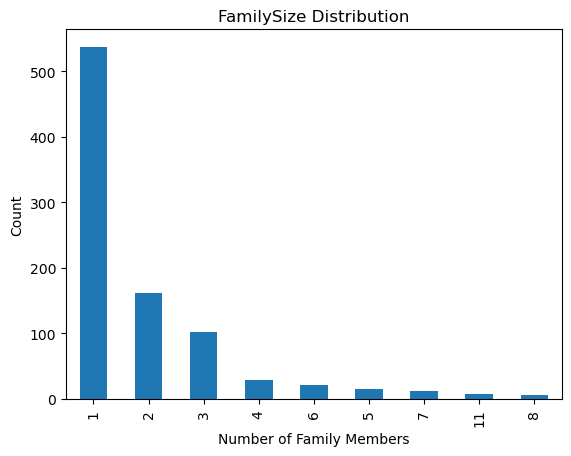

In [41]:
train_df['FamilySize'].value_counts().plot(kind='bar')

plt.title('FamilySize Distribution')
plt.xlabel('Number of Family Members')
plt.ylabel('Count')

plt.show()

In [42]:
pd.crosstab(train_df['FamilySize'], train_df['Survived'])

Survived,0,1
FamilySize,,
1,374,163
2,72,89
3,43,59
4,8,21
5,12,3
6,19,3
7,8,4
8,6,0
11,7,0


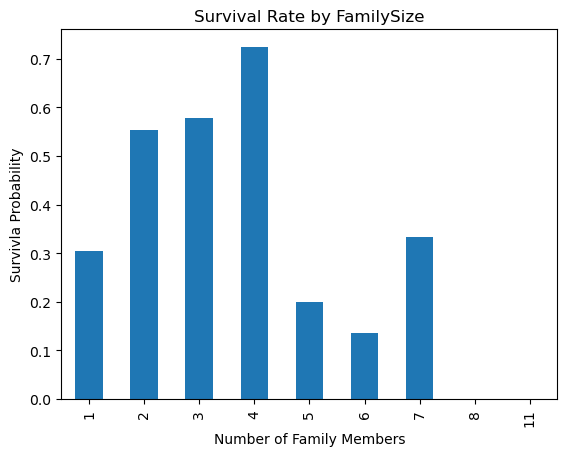

FamilySize
1     30.35
2     55.28
3     57.84
4     72.41
5     20.00
6     13.64
7     33.33
8      0.00
11     0.00
Name: Survived, dtype: float64

In [43]:
train_df.groupby('FamilySize')['Survived'].mean().plot(kind='bar')

plt.title('Survival Rate by FamilySize')
plt.xlabel('Number of Family Members')
plt.ylabel('Survivla Probability')

plt.show()
(train_df.groupby('FamilySize')['Survived'].mean() * 100).round(2)

In [44]:
# Feature 2: IsAlone

train_df['IsAlone'] = (train_df['FamilySize'] == 1).astype(int)
test_df['IsAlone'] = (train_df['FamilySize'] == 1).astype(int)

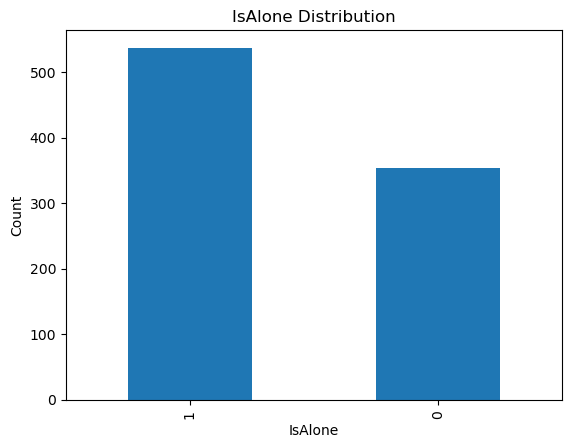

IsAlone
1    537
0    354
Name: count, dtype: int64

In [45]:
train_df['IsAlone'].value_counts().plot(kind='bar')

plt.title('IsAlone Distribution')
plt.ylabel('Count')

plt.show()
train_df['IsAlone'].value_counts()

In [46]:
pd.crosstab(train_df['IsAlone'], train_df['Survived'])

Survived,0,1
IsAlone,,
0,175,179
1,374,163


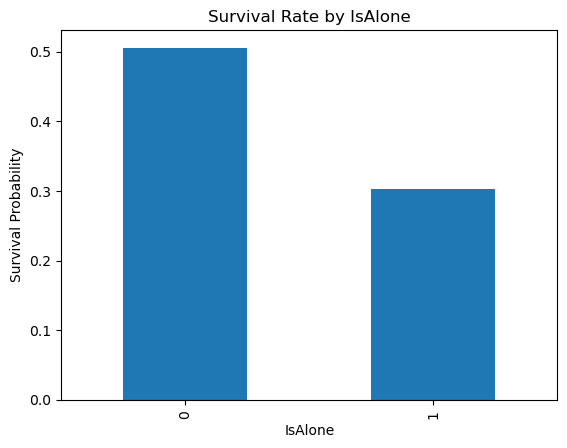

IsAlone
0    50.56
1    30.35
Name: Survived, dtype: float64

In [47]:
train_df.groupby('IsAlone')['Survived'].mean().plot(kind='bar')

plt.title('Survival Rate by IsAlone')
plt.ylabel('Survival Probability')

plt.show()

(train_df.groupby('IsAlone')['Survived'].mean() * 100).round(2)

In [48]:
# Feature 3: Title
train_df['Title'] = train_df['Name'].str.extract(r",\s*([^.]+)\.")
test_df['Title'] = test_df['Name'].str.extract(r",\s*([^.]+)\.")

In [49]:
train_df[['Name', 'Title']].sample(5)

,Name,Title
516,"Lemore, Mrs. (Amelia Milley)",Mrs
332,"Graham, Mr. George Edward",Mr
796,"Leader, Dr. Alice (Farnham)",Dr
712,"Taylor, Mr. Elmer Zebley",Mr
598,"Boulos, Mr. Hanna",Mr


In [50]:
train_df['Title'].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Col               2
Mlle              2
Major             2
Ms                1
Mme               1
Don               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

In [51]:
rare_titles = [
    "Lady",
    "the Countess",
    "Capt",
    "Col",
    "Don",
    "Dr",
    "Major",
    "Rev",
    "Sir",
    "Jonkheer",
    "Dona"
]

train_df['Title'] = train_df['Title'].replace(rare_titles, 'Rare')
train_df['Title'] = train_df['Title'].replace({
    "Mlle": "Miss",
    "Ms": "Miss",
    "Mme": "Mrs"
})


test_df['Title'] = test_df['Title'].replace(rare_titles, 'Rare')
test_df['Title'] = test_df['Title'].replace({
    "Mlle": "Miss",
    "Ms": "Miss",
    "Mme": "Mrs"
})

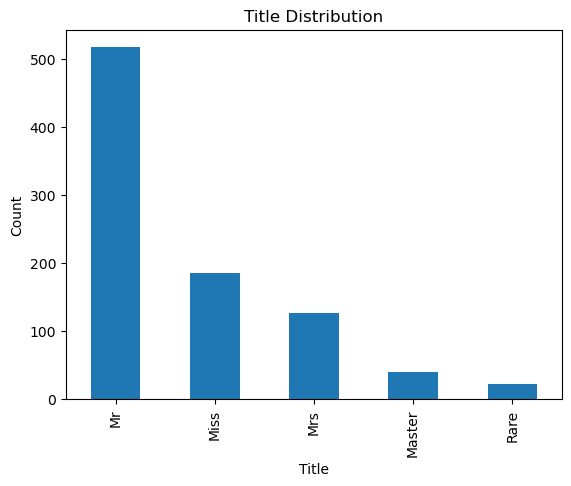

In [52]:
train_df['Title'].value_counts().plot(kind='bar')

plt.title('Title Distribution')
plt.ylabel('Count')

plt.show()

In [53]:
pd.crosstab(train_df['Title'], train_df['Survived'])

Survived,0,1
Title,,
Master,17,23
Miss,55,130
Mr,436,81
Mrs,26,100
Rare,15,8


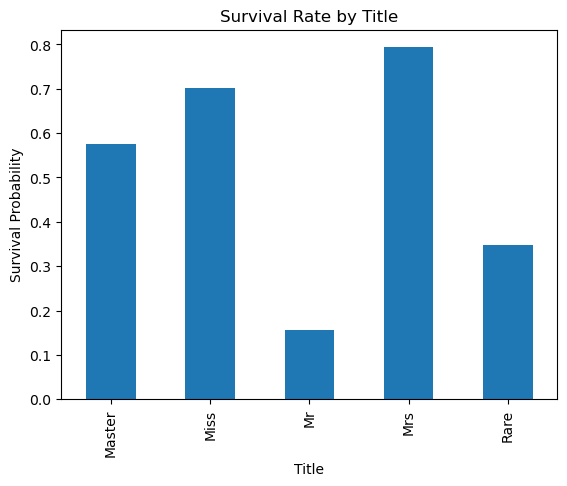

In [54]:
train_df.groupby('Title')['Survived'].mean().plot(kind='bar')

plt.title('Survival Rate by Title')
plt.ylabel('Survival Probability')

plt.show()

#### Pipeline (Version 2)

In [55]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression

In [56]:
train_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'FamilySize', 'IsAlone',
       'Title'],
      dtype='object')

In [57]:
numeric_features = ['Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone']
categorical_features = ['Pclass', 'Sex', 'Embarked', 'Title']

In [67]:
numerica_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])


categorical_pipelien = Pipeline([
    ('imupter', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

In [64]:
preprocessor = ColumnTransformer(
    transformers = [
        ('num', numerica_pipeline, numeric_features),
        ('cat', categorical_pipelien, categorical_features)
    ]
)

In [65]:
from sklearn.model_selection import train_test_split

X = train_df.drop(columns = 'Survived')
y = train_df['Survived']

X_train,X_valid,y_train,y_valid = train_test_split(X,y,test_size=0.2,random_state=42, stratify=y)

In [66]:
print(X_train.shape)
print(X_valid.shape)
print(y_train.shape)
print(y_valid.shape)

(712, 14)
(179, 14)
(712,)
(179,)


In [74]:
model_v2 = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

In [75]:
model_v2.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'SibSp', 'Parch',
                                                   'Fare', 'FamilySize',
                                                   'IsAlone']),
                                                 ('cat',
                                                  Pipeline(steps=[('impupter',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Pclass', 'Sex', 'Embarked',
                                                   'Title'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [81]:
model_v2.named_steps.preprocessor.get_feature_names_out()

array(['num__Age', 'num__SibSp', 'num__Parch', 'num__Fare',
       'num__FamilySize', 'num__IsAlone', 'cat__Pclass_2',
       'cat__Pclass_3', 'cat__Sex_male', 'cat__Embarked_Q',
       'cat__Embarked_S', 'cat__Title_Miss', 'cat__Title_Mr',
       'cat__Title_Mrs', 'cat__Title_Rare'], dtype=object)

In [83]:
y_pred2 = model_v2.predict(X_valid)

In [87]:
from sklearn.metrics import accuracy_score

print(f'Accuracy {accuracy_score(y_valid, y_pred2):.3f}')

Accuracy 0.832


In [89]:
from sklearn.metrics import classification_report

print(classification_report(y_valid, y_pred2))

              precision    recall  f1-score   support

           0       0.84      0.89      0.87       110
           1       0.81      0.74      0.77        69

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



[[98 12]
 [18 51]]


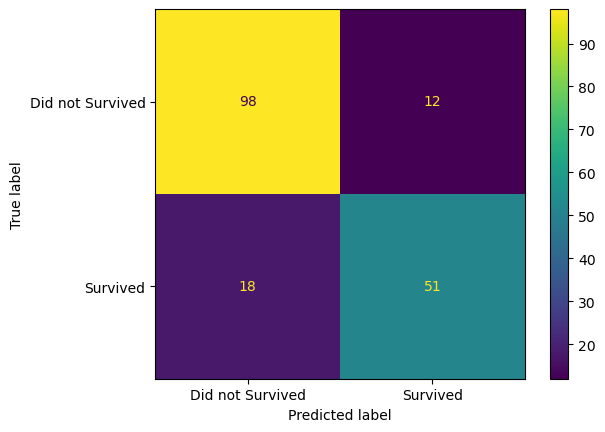

In [94]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_valid, y_pred2)

print(cm)

matrix_lbls = ['Did not Survived', 'Survived']
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels= matrix_lbls).plot()

plt.show()

In [115]:
trian_pred = model_v2.predict(X_train)
valid_pred = model_v2.predict(X_valid)

In [116]:
print(accuracy_score(y_train, trian_pred))
print(accuracy_score(y_valid, valid_pred))

0.824438202247191
0.8324022346368715


In [111]:
from sklearn.model_selection import cross_val_score
cvs = cross_val_score(model_v2, X, y, cv = 5, scoring='accuracy')
print('Fold Scores: ', cvs)
print('Mean Accuracy: ', cvs.mean())
print('Standard Deviation: ', cvs.std())

Fold Scores:  [0.83240223 0.81460674 0.80337079 0.79213483 0.84831461]
Mean Accuracy:  0.8181658401858012
Standard Deviation:  0.020103717382867082


#### Compare with Different Models

In [112]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

logistic_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

tree_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

forest_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

In [114]:
models = {
    'Logistic Regression': logistic_model,
    'Decision Tree': tree_model,
    'Random Forest': forest_model
}


for name, model in models.items():
    cvs = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring='accuracy'
    )

    print(f'{name}')
    print(f'Fold Scores: {cvs}')
    print(f'Mean Accuracy: {cvs.mean()}')
    print(f'Standard Deviation: {cvs.std()}')
    print("_"*40)

Logistic Regression
Fold Scores: [0.83240223 0.81460674 0.80337079 0.79213483 0.84831461]
Mean Accuracy: 0.8181658401858012
Standard Deviation: 0.020103717382867082
________________________________________
Decision Tree
Fold Scores: [0.77653631 0.78089888 0.82022472 0.74157303 0.78651685]
Mean Accuracy: 0.781149959199046
Standard Deviation: 0.025073181796620415
________________________________________
Random Forest
Fold Scores: [0.79888268 0.79213483 0.85393258 0.76404494 0.80898876]
Mean Accuracy: 0.8035967610319503
Standard Deviation: 0.02925991598410651
________________________________________


#### Predictions

In [117]:
predictions = model_v2.predict(test_df)

In [121]:
submission = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Survived": predictions
})

In [123]:
submission.to_csv(
    "../Data/submission.csv",
    index=False
)